In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import make_column_selector
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from math import sqrt

In [2]:
data=pd.read_csv('Student_Marks.csv')

In [3]:
data

,number_courses,time_study,Marks
0,3,4.508,19.202
1,4,0.096,7.734
2,4,3.133,13.811
3,6,7.909,53.018
4,8,7.811,55.299
...,...,...,...
95,6,3.561,19.128
96,3,0.301,5.609
97,4,7.163,41.444
98,7,0.309,12.027


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   number_courses  100 non-null    int64  
 1   time_study      100 non-null    float64
 2   Marks           100 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


In [5]:
data.duplicated().sum()

np.int64(0)

In [7]:
x=data[['number_courses','time_study']]
y=data.Marks

In [9]:
num_pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy='median')),
    ("scaler",SimpleImputer())
])

In [11]:
transformer=ColumnTransformer([
    ('num',num_pipeline,make_column_selector(dtype_include=np.number))
])

In [25]:
model_pipeline=Pipeline([
    ('preprocesing',transformer),
    ('poly',PolynomialFeatures(degree=2,include_bias=True)),
    ('model',LinearRegression())
])

In [26]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1,random_state=54)

In [27]:
x_train

,number_courses,time_study
85,8,6.201
92,4,5.027
91,8,2.730
32,8,0.932
0,3,4.508
...,...,...
64,7,0.130
23,7,4.875
15,4,4.260
2,4,3.133


In [28]:
x_test

,number_courses,time_study
36,4,2.966
70,4,3.736
48,3,5.635
94,8,3.919
81,8,2.262
46,4,3.797
38,7,6.533
29,4,1.299
34,3,4.083
22,5,2.051


In [29]:
y_train

85    39.957
92    23.916
91    19.564
32    15.038
0     19.202
       ...  
64    12.591
23    28.043
15    19.466
2     13.811
69    21.400
Name: Marks, Length: 90, dtype: float64

In [30]:
y_test

36    13.119
70    16.606
48    26.882
94    24.451
81    17.705
46    16.703
38    41.358
29     8.837
34    17.171
22    12.209
Name: Marks, dtype: float64

In [31]:
model_pipeline.fit(x_train,y_train)

Pipeline(steps=[('preprocesing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   SimpleImputer())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x00000224B3590E10>)])),
                ('poly', PolynomialFeatures()), ('model', LinearRegression())])

In [32]:
print(type(x_train))
print(x_train.head())

<class 'pandas.core.frame.DataFrame'>
    number_courses  time_study
85               8       6.201
92               4       5.027
91               8       2.730
32               8       0.932
0                3       4.508


In [34]:
y_pred_test=model_pipeline.predict(x_test)

In [35]:
sqrt(mean_squared_error(y_test,y_pred_test))

0.2477348182914182

In [37]:
r2_score(y_test,y_pred_test)

0.9992223433694527

In [38]:
def predict_student_score(number_courses, time_study):   
    new_input = pd.DataFrame({
        'number_courses': [number_courses], 
        'time_study': [time_study]
    })
    prediction = model_pipeline.predict(new_input)
    return prediction[0]



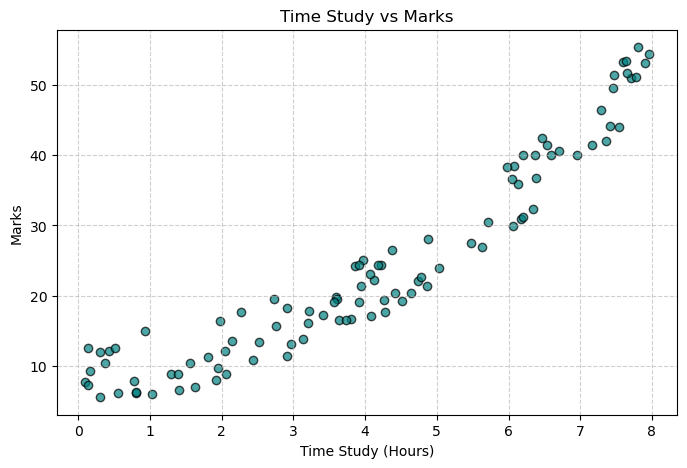

In [40]:
plt.figure(figsize=(8, 5))
plt.scatter(data['time_study'], data['Marks'], color='teal', alpha=0.7, edgecolors='black')
plt.title('Time Study vs Marks')
plt.xlabel('Time Study (Hours)')
plt.ylabel('Marks')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()